In [21]:
from pathlib import Path
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [7]:
BASE_DIR = Path.cwd().parent
RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
REPORTS_DIR = BASE_DIR / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

nav = pd.read_csv(PROCESSED_DIR / "02_nav_history_clean.csv")
funds = pd.read_csv(RAW_DIR / "01_fund_master.csv")

In [8]:
nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [9]:
var_cvar = (nav.groupby("amfi_code")["daily_return"].quantile(0.05).reset_index(name="var_95"))

In [10]:
def calculate_cvar(group):
    var = group["daily_return"].quantile(0.05)
    return group.loc[group["daily_return"] <= var, "daily_return"].mean()

cvar = (
    nav.groupby("amfi_code")
    .apply(calculate_cvar)
    .reset_index(name="cvar_95")
)

In [11]:
var_cvar_report = var_cvar.merge(
    cvar,
    on="amfi_code",
    how="left"
).merge(
    funds[["amfi_code", "scheme_name", "fund_house", "risk_category"]],
    on="amfi_code",
    how="left"
)

In [12]:
var_cvar_report = var_cvar_report[
    ["amfi_code", "scheme_name", "fund_house", "risk_category", "var_95", "cvar_95"]
]

var_cvar_report.to_csv(
    REPORTS_DIR / "var_cvar_report.csv",
    index=False
)

var_cvar_report.head()

,amfi_code,scheme_name,fund_house,risk_category,var_95,cvar_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Moderate,-0.012884,-0.016768
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Low,-0.003338,-0.004581
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,High,-0.016902,-0.021850
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Moderate,-0.012173,-0.016075
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Very High,-0.023915,-0.030289


In [13]:
nav["rolling_sharpe_90"] = (
    nav.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).mean() / x.rolling(90).std() * np.sqrt(252))
)

In [ ]:
key_funds = [
    148567,
    120843,
    148569,
    119551,
    120505
]
rolling_sharpe = nav[nav["amfi_code"].isin(key_funds)].copy()
rolling_sharpe = rolling_sharpe.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [24]:
fig = px.line(
    rolling_sharpe,
    x="date",
    y="rolling_sharpe_90",
    color="scheme_name",
    title="90-Day Rolling Sharpe Ratio"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Rolling Sharpe Ratio",
    legend_title="Fund"
)
fig.write_image(REPORTS_DIR / "rolling_sharpe_chart.png",width=1400,height=800,scale=2)
fig.show()

In [25]:
transactions = pd.read_csv(PROCESSED_DIR / "08_investor_transactions_clean.csv")
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

In [26]:
first_transaction = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index(name="first_transaction_date")
)

first_transaction["cohort_year"] = (
    first_transaction["first_transaction_date"].dt.year
)

first_transaction.head()

,investor_id,first_transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [ ]:
transactions = transactions.merge(
    first_transaction[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [28]:
cohort_summary = (
    transactions.groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr", lambda x: transactions.loc[x.index][transactions.loc[x.index, "transaction_type"] == "SIP"]["amount_inr"].mean()),
        total_invested=("amount_inr", "sum"),
        investors=("investor_id", "nunique")
    )
    .reset_index()
)
cohort_summary

,cohort_year,avg_sip_amount,total_invested,investors
0,2024,10996.885825,3491125187,4803
1,2025,13505.209581,30455243,197


In [ ]:
cohort_fund_preference = (
    transactions.groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="transaction_count")
)

cohort_fund_preference = cohort_fund_preference.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

cohort_fund_preference = cohort_fund_preference.sort_values(
    ["cohort_year", "transaction_count"],
    ascending=[True, False]
)

cohort_fund_preference = (
    cohort_fund_preference
    .groupby("cohort_year")
    .first()
    .reset_index()
)
cohort_fund_preference

,cohort_year,amfi_code,transaction_count,scheme_name
0,2024,148568,874,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,119599,12,SBI Small Cap Fund - Direct Plan - Growth


In [30]:
cohort_summary = cohort_summary.merge(
    cohort_fund_preference[
        ["cohort_year", "scheme_name", "transaction_count"]
    ],
    on="cohort_year",
    how="left"
)
cohort_summary

,cohort_year,avg_sip_amount,total_invested,investors,scheme_name,transaction_count
0,2024,10996.885825,3491125187,4803,Mirae Asset Emerging Bluechip Fund - Regular -...,874
1,2025,13505.209581,30455243,197,SBI Small Cap Fund - Direct Plan - Growth,12


In [31]:
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip_transactions = sip_transactions.sort_values(
    ["investor_id", "transaction_date"]
)
sip_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [32]:
sip_transactions["gap_days"] = (
    sip_transactions.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)
sip_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0


In [33]:
sip_continuity = (
    sip_transactions.groupby("investor_id")
    .agg(
        sip_count=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean")
    )
    .reset_index()
)

sip_continuity = sip_continuity[
    sip_continuity["sip_count"] >= 6
].copy()

sip_continuity["continuity_status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "at-risk",
    "regular"
)
sip_continuity.head()

,investor_id,sip_count,avg_gap_days,continuity_status
3,INV000004,6,85.400000,at-risk
7,INV000008,6,70.400000,at-risk
9,INV000010,6,64.800000,at-risk
10,INV000011,7,40.166667,at-risk
11,INV000012,8,57.000000,at-risk


In [ ]:
continuity_rate = (
    sip_continuity["continuity_status"].eq("regular").mean() * 100
)
continuity_rate

np.float64(2.2026431718061676)

In [35]:
sip_continuity["continuity_status"].value_counts()

continuity_status
at-risk    1332
regular      30
Name: count, dtype: int64

In [37]:
performance = pd.read_csv(PROCESSED_DIR / "07_scheme_performance_clean.csv")
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,scheme_aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,anomaly_flag
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False


In [38]:
performance["risk_grade"].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [ ]:
risk_appetite = "Moderate"
risk_appetite

'Moderate'

In [40]:
recommended_funds = performance[
    performance["risk_grade"] == risk_appetite
].copy()
recommended_funds.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,scheme_aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,anomaly_flag
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate,False
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,Large Cap,Direct,11.48,13.38,13.48,12.25,1.13,0.97,0.96,1.45,14.0,-33.50,10611,0.92,4,Moderate,False
10,120503,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF,Large Cap,Regular,15.63,11.54,11.46,10.88,0.66,0.96,0.82,1.12,14.0,-25.91,36022,1.42,4,Moderate,False


In [ ]:
recommended_funds = recommended_funds.sort_values(
    "sharpe_ratio",
    ascending=False
)
recommended_funds.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,scheme_aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,anomaly_flag
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate,False
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate,False
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate,False
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Large Cap,Regular,15.84,14.00,14.70,13.14,0.86,0.88,1.00,1.68,14.0,-16.07,20909,1.51,4,Moderate,False
28,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap,Regular,14.82,13.78,12.86,12.44,1.34,1.03,0.98,1.25,14.0,-15.07,23500,1.60,5,Moderate,False


In [42]:
top_3_funds = recommended_funds.head(3)
top_3_funds

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,scheme_aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,anomaly_flag
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate,False
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate,False
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate,False


In [43]:
recommendation_table = top_3_funds[["scheme_name", "fund_house", "risk_grade", "sharpe_ratio"]]
recommendation_table

,scheme_name,fund_house,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Moderate,1.03


In [53]:
print("Risk Appetite:", risk_appetite)
print(recommendation_table.to_string(index=False))

Risk Appetite: Moderate
                                  scheme_name          fund_house risk_grade  sharpe_ratio
    HDFC Top 100 Fund - Regular Plan - Growth    HDFC Mutual Fund   Moderate          1.06
Mirae Asset Large Cap Fund - Regular - Growth      Mirae Asset MF   Moderate          1.06
    ICICI Pru Bluechip Fund - Direct - Growth ICICI Prudential MF   Moderate          1.03


In [56]:
holdings = pd.read_csv(RAW_DIR / "09_portfolio_holdings.csv")
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [58]:
equity_funds = funds[
    funds["category"].str.contains("Equity", case=False, na=False)
]

equity_funds[["amfi_code", "scheme_name", "category"]].head()

,amfi_code,scheme_name,category
0,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity
1,119552,SBI Bluechip Fund - Direct Plan - Growth,Equity
2,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity
3,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,Equity


In [59]:
equity_holdings = holdings[
    holdings["amfi_code"].isin(equity_funds["amfi_code"])
].copy()
equity_holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [60]:
sector_weights = (
    equity_holdings
    .groupby(["amfi_code", "sector"])["weight_pct"]
    .sum()
    .reset_index()
)
sector_weights.head()

,amfi_code,sector,weight_pct
0,100016,Automobile,14.84
1,100016,Banking,3.39
2,100016,Energy,6.09
3,100016,FMCG,11.68
4,100016,IT,25.90


In [61]:
hhi_by_fund = (
    sector_weights
    .assign(weight_share=lambda x: x["weight_pct"] / 100)
    .groupby("amfi_code")["weight_share"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="hhi")
)
hhi_by_fund.head()

,amfi_code,hhi
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712


In [62]:
hhi_by_fund = hhi_by_fund.merge(
    equity_funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)
hhi_by_fund = hhi_by_fund[
    ["amfi_code", "scheme_name", "hhi"]
]
hhi_by_fund.head()

,amfi_code,scheme_name,hhi
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.180588
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.227647
2,101206,ABSL Frontline Equity Fund - Regular - Growth,0.180042
3,101207,ABSL Small Cap Fund - Regular - Growth,0.222727
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.180712


In [63]:
hhi_by_fund = hhi_by_fund.sort_values(
    "hhi",
    ascending=False
)
hhi_by_fund.head(10)

,amfi_code,scheme_name,hhi
11,119092,Axis Bluechip Fund - Regular - Growth,0.296769
30,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.254992
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.253155
6,102887,UTI Flexi Cap Fund - Regular - Growth,0.251383
32,149323,DSP Midcap Fund - Regular - Growth,0.241077
21,120505,ICICI Pru Midcap Fund - Regular - Growth,0.238695
10,118635,Nippon India ETF Nifty 50 BeES,0.237497
18,119599,SBI Small Cap Fund - Direct Plan - Growth,0.232361
22,120506,ICICI Pru Value Discovery Fund - Regular - Growth,0.231464
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.227647


In [64]:
hhi_by_fund["concentration"] = np.where(
    hhi_by_fund["hhi"] >= 0.15,
    "High",
    np.where(
        hhi_by_fund["hhi"] >= 0.10,
        "Moderate",
        "Low"
    )
)
hhi_by_fund.head(10)

,amfi_code,scheme_name,hhi,concentration
11,119092,Axis Bluechip Fund - Regular - Growth,0.296769,High
30,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.254992,High
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.253155,High
6,102887,UTI Flexi Cap Fund - Regular - Growth,0.251383,High
32,149323,DSP Midcap Fund - Regular - Growth,0.241077,High
21,120505,ICICI Pru Midcap Fund - Regular - Growth,0.238695,High
10,118635,Nippon India ETF Nifty 50 BeES,0.237497,High
18,119599,SBI Small Cap Fund - Direct Plan - Growth,0.232361,High
22,120506,ICICI Pru Value Discovery Fund - Regular - Growth,0.231464,High
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.227647,High


In [65]:
hhi_by_fund[["scheme_name", "hhi", "concentration"]].head(10)

,scheme_name,hhi,concentration
11,Axis Bluechip Fund - Regular - Growth,0.296769,High
30,Mirae Asset Tax Saver Fund - Regular - Growth,0.254992,High
27,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.253155,High
6,UTI Flexi Cap Fund - Regular - Growth,0.251383,High
32,DSP Midcap Fund - Regular - Growth,0.241077,High
21,ICICI Pru Midcap Fund - Regular - Growth,0.238695,High
10,Nippon India ETF Nifty 50 BeES,0.237497,High
18,SBI Small Cap Fund - Direct Plan - Growth,0.232361,High
22,ICICI Pru Value Discovery Fund - Regular - Growth,0.231464,High
1,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.227647,High


In [66]:
var_cvar_report.sort_values("var_95").head(5)

,amfi_code,scheme_name,fund_house,risk_category,var_95,cvar_95
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Very High,-0.023915,-0.030289
17,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Very High,-0.023284,-0.029690
22,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Very High,-0.023155,-0.030163
11,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Very High,-0.022810,-0.029940
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Very High,-0.021520,-0.028573


## Advanced Insights

In [67]:
cohort_summary.sort_values(
    "total_invested",
    ascending=False
).head()

,cohort_year,avg_sip_amount,total_invested,investors,scheme_name,transaction_count
0,2024,10996.885825,3491125187,4803,Mirae Asset Emerging Bluechip Fund - Regular -...,874
1,2025,13505.209581,30455243,197,SBI Small Cap Fund - Direct Plan - Growth,12


The 2024 investor cohort invested the most, with approximately ₹3.49 billion in total investment across 4,803 investors. Their average SIP amount was ₹10,996.89, and Mirae Asset Emerging Bluechip Fund was their most preferred fund based on transaction count.

In [69]:
sip_continuity["continuity_status"].value_counts()

continuity_status
at-risk    1332
regular      30
Name: count, dtype: int64

SIP continuity was low among investors with at least 6 SIP transactions. Only 2.20% of investors were classified as regular, while 97.80% were classified as at-risk because their average SIP gap exceeded 35 days. This indicates weak SIP continuity in the analyzed investor group.

In [70]:
hhi_by_fund[["scheme_name", "hhi", "concentration"]].head(5)

,scheme_name,hhi,concentration
11,Axis Bluechip Fund - Regular - Growth,0.296769,High
30,Mirae Asset Tax Saver Fund - Regular - Growth,0.254992,High
27,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.253155,High
6,UTI Flexi Cap Fund - Regular - Growth,0.251383,High
32,DSP Midcap Fund - Regular - Growth,0.241077,High


The HHI analysis shows that sector concentration varies across equity funds. Funds with higher HHI values have more concentrated sector exposure, while lower HHI values indicate better sector diversification. This highlights differences in portfolio concentration and diversification across the equity fund universe.

In [72]:
performance.sort_values(
    "sharpe_ratio",
    ascending=False
)[["scheme_name", "sharpe_ratio", "return_3yr_pct"]].head(5)

,scheme_name,sharpe_ratio,return_3yr_pct
14,ICICI Pru Liquid Fund - Regular - Growth,7.68,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84,7.37
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52,6.07


The fund performance analysis shows that funds with higher Sharpe ratios delivered better risk-adjusted returns over the analyzed period. These funds provided stronger returns relative to the volatility taken, making the Sharpe ratio a useful metric for comparing risk-adjusted fund performance.

## Markowitz Efficient Frontier Portfolio Optimization

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
NAV_FILE = PROJECT_ROOT / "data" / "processed" / "02_nav_history_clean.csv"

nav = pd.read_csv(NAV_FILE)
nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [2]:
selected_codes = [148567, 120504, 148569, 119551, 120505]
nav_selected = nav[nav["amfi_code"].isin(selected_codes)].copy()
nav_selected = nav_selected.sort_values(["date", "amfi_code"])

nav_selected.head()

,amfi_code,date,nav
30552,119551,2022-01-03,54.3856
38592,120504,2022-01-03,60.1474
40200,120505,2022-01-03,135.8720
54672,148567,2022-01-03,70.2514
57888,148569,2022-01-03,28.8620


In [3]:
returns = nav_selected.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)
returns = returns.pct_change().dropna()

returns.head()

amfi_code,119551,120504,120505,148567,148569
date,,,,,
2022-01-04,-0.000702,-0.011467,-0.019900,0.019318,0.008378
2022-01-05,0.006247,0.013923,0.030352,-0.003939,0.015294
2022-01-06,0.014045,0.003893,-0.004917,0.011892,0.000863
2022-01-07,-0.001547,0.001935,0.009655,0.000515,0.001173
2022-01-08,0.000000,0.000000,0.000000,0.000000,0.000000


In [4]:
annual_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

print(annual_returns)
print(cov_matrix)

amfi_code
119551    0.165188
120504    0.151899
120505    0.209246
148567    0.193454
148569    0.202531
dtype: float64
amfi_code    119551    120504    120505    148567    148569
amfi_code                                                  
119551     0.013541  0.000058  0.000187  0.000120 -0.000222
120504     0.000058  0.014785  0.000053 -0.000730 -0.001102
120505     0.000187  0.000053  0.026671 -0.000187  0.000316
148567     0.000120 -0.000730 -0.000187  0.014460  0.000246
148569    -0.000222 -0.001102  0.000316  0.000246  0.022394


In [7]:
num_portfolios = 10000
num_funds = len(selected_codes)

portfolio_returns = []
portfolio_volatility = []
portfolio_sharpe = []
portfolio_weights = []

for _ in range(num_portfolios):
    weights = np.random.random(num_funds)
    weights = weights / weights.sum()

    portfolio_return = np.dot(weights, annual_returns)
    portfolio_vol = np.sqrt(
        np.dot(weights.T, np.dot(cov_matrix, weights))
    )
    portfolio_sharpe_ratio = portfolio_return / portfolio_vol

    portfolio_returns.append(portfolio_return)
    portfolio_volatility.append(portfolio_vol)
    portfolio_sharpe.append(portfolio_sharpe_ratio)
    portfolio_weights.append(weights)

portfolio_returns = np.array(portfolio_returns)
portfolio_volatility = np.array(portfolio_volatility)
portfolio_sharpe = np.array(portfolio_sharpe)
portfolio_weights = np.array(portfolio_weights)

print("Portfolios:", len(portfolio_returns))

Portfolios: 10000


In [8]:
max_sharpe_index = np.argmax(portfolio_sharpe)
min_volatility_index = np.argmin(portfolio_volatility)

max_sharpe_return = portfolio_returns[max_sharpe_index]
max_sharpe_volatility = portfolio_volatility[max_sharpe_index]

min_volatility_return = portfolio_returns[min_volatility_index]
min_volatility_volatility = portfolio_volatility[min_volatility_index]

print("Maximum Sharpe Portfolio")
print("Return:", max_sharpe_return)
print("Risk:", max_sharpe_volatility)
print("Sharpe Ratio:", portfolio_sharpe[max_sharpe_index])

print("\nMinimum Volatility Portfolio")
print("Return:", min_volatility_return)
print("Risk:", min_volatility_volatility)

Maximum Sharpe Portfolio
Return: 0.1809959443427716
Risk: 0.05745099316760587
Sharpe Ratio: 3.150440651473844

Minimum Volatility Portfolio
Return: 0.1794721599564118
Risk: 0.057390181257548814


In [9]:
fund_names = {
    148567: "Mirae Asset Large Cap Fund",
    120504: "ICICI Prudential Midcap Fund",
    148569: "Kotak Flexicap Fund",
    119551: "HDFC Mid-Cap Opportunities Fund",
    120505: "ICICI Prudential Bluechip Fund"
}

max_sharpe_weights = portfolio_weights[max_sharpe_index]
min_volatility_weights = portfolio_weights[min_volatility_index]

max_sharpe_portfolio = pd.DataFrame({
    "Fund": [fund_names[code] for code in selected_codes],
    "Weight": max_sharpe_weights * 100
})

min_volatility_portfolio = pd.DataFrame({
    "Fund": [fund_names[code] for code in selected_codes],
    "Weight": min_volatility_weights * 100
})

print("Maximum Sharpe Portfolio")
print(max_sharpe_portfolio.to_string(index=False))

print("\nMinimum Volatility Portfolio")
print(min_volatility_portfolio.to_string(index=False))

Maximum Sharpe Portfolio
                           Fund    Weight
     Mirae Asset Large Cap Fund 23.094096
   ICICI Prudential Midcap Fund 22.907619
            Kotak Flexicap Fund 13.320655
HDFC Mid-Cap Opportunities Fund 24.314424
 ICICI Prudential Bluechip Fund 16.363206

Minimum Volatility Portfolio
                           Fund    Weight
     Mirae Asset Large Cap Fund 23.857006
   ICICI Prudential Midcap Fund 25.182461
            Kotak Flexicap Fund 11.126519
HDFC Mid-Cap Opportunities Fund 23.650887
 ICICI Prudential Bluechip Fund 16.183128


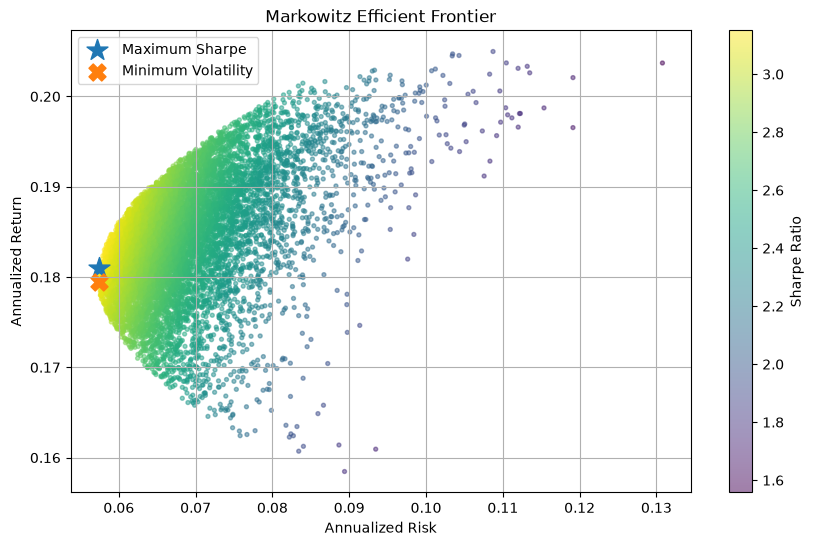

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    portfolio_volatility,
    portfolio_returns,
    c=portfolio_sharpe,
    cmap="viridis",
    s=8,
    alpha=0.5
)

plt.scatter(
    max_sharpe_volatility,
    max_sharpe_return,
    marker="*",
    s=250,
    label="Maximum Sharpe"
)

plt.scatter(
    min_volatility_volatility,
    min_volatility_return,
    marker="X",
    s=150,
    label="Minimum Volatility"
)

plt.xlabel("Annualized Risk")
plt.ylabel("Annualized Return")
plt.title("Markowitz Efficient Frontier")
plt.colorbar(scatter, label="Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.show()

Interpretation: The Markowitz portfolio optimization evaluates multiple combinations of the five selected mutual funds based on expected return and portfolio risk. The Efficient Frontier represents portfolios offering the best expected return for a given level of risk. The Maximum Sharpe Portfolio provides the best risk-adjusted return, while the Minimum Volatility Portfolio provides the lowest portfolio risk.